# Part B · NB1 — SimCLR   ·  `pavecrack1300-partb-simclr`

**Course:** CSE 438 — Digital Image Processing · Dept. of CSE, **East West University** · Summer 2026
**Instructor:** _`Mohammad Rifat Ahmmad Rashid`_ · **Group:** _`C`_ · **Section:** _`<4>`_

| # | Name | Student ID |
|---|---|---|
| 1 | Mantasha Rahman Mahi | 2022-3-60-194 |
| 2 | Jannatul Ferdous Nabila | 2022-3-60-198 | 
| 3 | Nazratan Mazumder Niha | 2022-3-60-328 | 
| 4 | Sabiha Nusrat | 2022-1-60-303 |

**Method:** **SimCLR** — contrastive matching (NT-Xent) · backbone **ResNet-50**.
**Pipeline (Part B):** SSL-pretrain the encoder on the Part-A **train** split (unlabelled, 50 ep) → attach the
Part-A best decoder (**DeepLabV3 ASPP head**) → fine-tune on the Part-A **val** split (195 labelled, 50 ep) →
monitor + evaluate on the Part-A **test** split. *(# debugged/authored with AI assistance where noted.)*

**Attach:** raw **PaveCrack1300** + committed **Part-B data-prep output** (`partB_roles.json`). **GPU (T4) ON.**

In [1]:
# ---- setup & imports (version-pinned) ----
import os, gc, json, glob, time, math, random, copy, warnings
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "albumentations"], check=False)
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything()
print("torch", torch.__version__, "| device", DEVICE, "| GPU:",
      torch.cuda.get_device_name(0) if DEVICE == "cuda" else "-")

def amp_ctx():
    return torch.autocast("cuda", enabled=(DEVICE == "cuda"))
try:
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

torch 2.10.0+cu128 | device cuda | GPU: Tesla T4


In [2]:
# ---- load Part-B role mapping (from data-prep) + resolve raw paths ----
def _find(p):
    h = glob.glob(p, recursive=True); return h[0] if h else None
PB = json.load(open(_find("/kaggle/input/**/partB_roles.json")))
IMG_SIZE = PB["resolution"]; NUM_CLASSES = PB["num_classes"]; CLASS_NAMES = PB["class_names"]
train_recs, val_recs, test_recs = PB["train"], PB["val"], PB["test"]
print("roles:", PB["counts"], "| label-efficiency", PB["label_efficiency_ratio"])

IMGS  = glob.glob("/kaggle/input/**/images/images/*.jpg", recursive=True) or \
        glob.glob("/kaggle/input/**/images/**/*.jpg", recursive=True)
MASKS = glob.glob("/kaggle/input/**/masks/**/*.png", recursive=True)
PATH_BY_NAME = {Path(p).name: p for p in IMGS}
MASK_BY_NAME = {Path(p).name: p for p in MASKS}
assert PATH_BY_NAME and MASK_BY_NAME, "attach the raw PaveCrack1300 dataset"
WORK = Path("/kaggle/working"); WORK.mkdir(exist_ok=True)
IMAGENET_MEAN = (0.485, 0.456, 0.406); IMAGENET_STD = (0.229, 0.224, 0.225)

roles: {'train': 909, 'val': 195, 'test': 196} | label-efficiency 0.2145


In [3]:
# ---- datasets: SSL two-view (images only) · labelled seg · test ----
def _try(cls, *vs):
    last = None
    for kw in vs:
        try: return cls(**kw)
        except (TypeError, ValueError) as e: last = e
    raise RuntimeError(str(last))
import cv2
def _geom(p=0.5):
    if hasattr(A, "ShiftScaleRotate"):
        try: return A.ShiftScaleRotate(0.0625, 0.1, 15, border_mode=cv2.BORDER_REFLECT_101, p=p)
        except (TypeError, ValueError): pass
    return _try(A.Affine, dict(translate_percent=0.0625, scale=(0.9,1.1), rotate=(-15,15), p=p))

label_tf = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.HorizontalFlip(0.5), A.VerticalFlip(0.5),
                      A.RandomRotate90(0.5), _geom(0.5), A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
                      A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()])
test_tf = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()])

class LabeledSeg(Dataset):
    def __init__(self, recs, aug): self.recs, self.aug = recs, aug
    def __len__(self): return len(self.recs)
    def __getitem__(self, i):
        r = self.recs[i]
        img = np.array(Image.open(PATH_BY_NAME[r["image"]]).convert("RGB"))
        m = (np.array(Image.open(MASK_BY_NAME[r["mask"]])) > 0).astype("uint8")
        o = self.aug(image=img, mask=m); return o["image"], o["mask"].long(), r["sample_id"]

class SSLTwoView(Dataset):
    def __init__(self, recs, tf): self.recs, self.tf = recs, tf
    def __len__(self): return len(self.recs)
    def __getitem__(self, i):
        img = Image.open(PATH_BY_NAME[self.recs[i]["image"]]).convert("RGB")
        return self.tf(img), self.tf(img)

val_loader  = DataLoader(LabeledSeg(val_recs,  label_tf), batch_size=8,  shuffle=True,  num_workers=2, drop_last=False)
test_loader = DataLoader(LabeledSeg(test_recs, test_tf),  batch_size=8,  shuffle=False, num_workers=2)
print("labelled(val):", len(val_recs), "| test:", len(test_recs), "| unlabelled(train):", len(train_recs))

labelled(val): 195 | test: 196 | unlabelled(train): 909


In [4]:
# ---- metrics + loss (same confusion-matrix source of truth as Part A) ----
class ConfMat:
    def __init__(s, n): s.n = n; s.mat = torch.zeros(n, n, dtype=torch.int64)
    def update(s, p, t):
        p = p.flatten(); t = t.flatten(); k = (t >= 0) & (t < s.n)
        s.mat += torch.bincount(s.n * t[k] + p[k], minlength=s.n**2).reshape(s.n, s.n).cpu()
    def compute(s):
        m = s.mat.double(); tp = m.diag(); fp = m.sum(0) - tp; fn = m.sum(1) - tp
        iou = tp / (tp + fp + fn).clamp(min=1e-9); dice = 2*tp / (2*tp + fp + fn).clamp(min=1e-9)
        return dict(iou=iou.tolist(), miou=iou.mean().item(), dice=dice.tolist(), mdice=dice.mean().item(),
                    pixel_acc=(tp.sum()/m.sum().clamp(min=1e-9)).item(),
                    mean_pixel_acc=(tp/m.sum(1).clamp(min=1e-9)).mean().item())
def per_image_iou(p, t, c=1):
    p = (p == c); t = (t == c); inter = int((p & t).sum()); union = int((p | t).sum())
    return inter/union if union else float("nan")
class DiceLoss(nn.Module):
    def forward(s, logits, tgt):
        pr = torch.softmax(logits, 1); oh = F.one_hot(tgt, logits.shape[1]).permute(0,3,1,2).float()
        d = (2*(pr*oh).sum((0,2,3)) + 1e-6) / ((pr+oh).sum((0,2,3)) + 1e-6); return 1 - d.mean()
class ComboLoss(nn.Module):
    def __init__(s, w=(0.56, 4.63)):
        super().__init__(); s.ce = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32)); s.d = DiceLoss()
    def forward(s, logits, tgt): return s.ce(logits, tgt) + s.d(logits, tgt)
criterion = ComboLoss().to(DEVICE)
print("metrics + Dice+CE loss ready")

metrics + Dice+CE loss ready


## Task B — SimCLR pretraining (ResNet-50, NT-Xent, 50 ep)
Two augmented views of each image; the encoder learns to pull the two views together and push different images
apart via the **NT-Xent** contrastive loss. No labels used.

  SSL ep 01 NT-Xent 4.7512
  SSL ep 05 NT-Xent 4.0447
  SSL ep 10 NT-Xent 3.2728
  SSL ep 15 NT-Xent 3.1005
  SSL ep 20 NT-Xent 2.9222
  SSL ep 25 NT-Xent 2.5321
  SSL ep 30 NT-Xent 2.3191
  SSL ep 35 NT-Xent 2.2412
  SSL ep 40 NT-Xent 2.1291
  SSL ep 45 NT-Xent 1.9658
  SSL ep 50 NT-Xent 1.9619
SimCLR pretraining done: 32.9 min (0.66 min/ep)


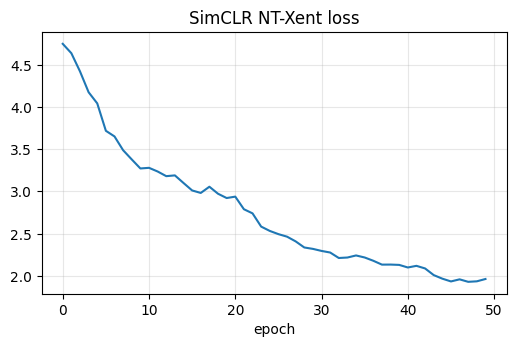

In [5]:
from torchvision.models import resnet50
simclr_tf = T.Compose([T.RandomResizedCrop(IMG_SIZE, scale=(0.6,1.0), antialias=True),
    T.RandomHorizontalFlip(0.5), T.RandomVerticalFlip(0.5),
    T.RandomApply([T.ColorJitter(0.4,0.4,0.2,0.1)], p=0.8), T.RandomApply([T.GaussianBlur(23,(0.1,2.0))], p=0.5),
    T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
ssl_loader = DataLoader(SSLTwoView(train_recs, simclr_tf), batch_size=64, shuffle=True, num_workers=2, drop_last=True)

class SimCLR(nn.Module):
    def __init__(s):
        super().__init__(); s.encoder = resnet50(weights=None); d = s.encoder.fc.in_features; s.encoder.fc = nn.Identity()
        s.proj = nn.Sequential(nn.Linear(d,512), nn.ReLU(True), nn.Linear(512,128))
    def forward(s, x): return s.proj(s.encoder(x))
def nt_xent(z1, z2, temp=0.2):
    # NT-Xent in float32 (AMP stability): float16 cannot hold the large negative diagonal fill.
    with torch.autocast(device_type="cuda", enabled=False):
        z = F.normalize(torch.cat([z1, z2]).float(), dim=1); N = z1.size(0)
        sim = (z @ z.t()) / temp
        sim.fill_diagonal_(float("-inf"))
        targets = torch.arange(2*N, device=z.device); targets = (targets + N) % (2*N)
        return F.cross_entropy(sim, targets)

SSL_EPOCHS = 50
ssl_model = SimCLR().to(DEVICE); opt = torch.optim.AdamW(ssl_model.parameters(), lr=1e-3, weight_decay=1e-4)
ssl_hist = []; t0 = time.time()
for ep in range(1, SSL_EPOCHS+1):
    ssl_model.train(); run = 0.0
    for a, b in ssl_loader:
        a, b = a.to(DEVICE), b.to(DEVICE); opt.zero_grad(set_to_none=True)
        with amp_ctx(): loss = nt_xent(ssl_model(a), ssl_model(b))
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); run += loss.item()
    ssl_hist.append(run/len(ssl_loader))
    if ep % 5 == 0 or ep == 1: print(f"  SSL ep {ep:02d} NT-Xent {ssl_hist[-1]:.4f}")
ssl_minutes = (time.time()-t0)/60
print(f"SimCLR pretraining done: {ssl_minutes:.1f} min ({ssl_minutes/SSL_EPOCHS:.2f} min/ep)")
plt.figure(figsize=(6,3.4)); plt.plot(ssl_hist); plt.title("SimCLR NT-Xent loss"); plt.xlabel("epoch"); plt.grid(alpha=.3)
plt.savefig(WORK/"SimCLR_pretrain_loss.png", dpi=110); plt.show()
pretrained_encoder = ssl_model.encoder

In [6]:
# ---- attach DeepLabV3 ASPP head: transfer the SSL-pretrained ResNet-50 into deeplabv3_resnet50 ----
from torchvision.models.segmentation import deeplabv3_resnet50
def build_seg_from_resnet(encoder, frozen=False):
    model = deeplabv3_resnet50(weights=None, weights_backbone=None, num_classes=NUM_CLASSES, aux_loss=True)
    rep = model.backbone.load_state_dict(encoder.state_dict(), strict=False)   # ResNet-50 layers transfer; fc/proj ignored
    print("  transferred SSL encoder -> deeplab backbone | missing", len(rep.missing_keys), "unexpected", len(rep.unexpected_keys))
    if frozen:
        for p in model.backbone.parameters(): p.requires_grad_(False)
    return model.to(DEVICE)
def _is_encoder(name): return name.startswith("backbone.")
def seg_logits(model, x): return model(x)["out"]
def seg_train_forward(model, x, y):
    out = model(x); loss = criterion(out["out"], y) + 0.4*criterion(out["aux"], y); return loss, out["out"]

In [7]:
# ---- fine-tune (val split, 50 ep) · monitor test crack-IoU · checkpoint best ----
FT_EPOCHS = 50
def finetune(model, tag, enc_lr, dec_lr):
    enc_params = [p for n, p in model.named_parameters() if p.requires_grad and _is_encoder(n)]
    dec_params = [p for n, p in model.named_parameters() if p.requires_grad and not _is_encoder(n)]
    opt = torch.optim.AdamW([{"params": enc_params, "lr": enc_lr}, {"params": dec_params, "lr": dec_lr}], weight_decay=1e-2)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FT_EPOCHS)
    hist = defaultdict(list); best = -1; best_state = None; t0 = time.time()
    for ep in range(1, FT_EPOCHS+1):
        model.train(); run = 0.0
        for x, y, _ in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE); opt.zero_grad(set_to_none=True)
            with amp_ctx(): loss, _ = seg_train_forward(model, x, y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); run += loss.item()*x.size(0)
        sch.step()
        cm = ConfMat(NUM_CLASSES); model.eval(); vl = 0.0
        with torch.no_grad():
            for x, y, _ in test_loader:
                x = x.to(DEVICE)
                with amp_ctx(): lo = seg_logits(model, x)
                vl += criterion(lo, y.to(DEVICE)).item()*x.size(0); cm.update(lo.argmax(1).cpu(), y)
        met = cm.compute(); ci = met["iou"][1]
        hist["train_loss"].append(run/len(val_recs)); hist["test_loss"].append(vl/len(test_recs))
        hist["test_miou"].append(met["miou"]); hist["test_crack_iou"].append(ci)
        if ci > best: best = ci; best_ep = ep; best_state = copy.deepcopy(model.state_dict())
        if ep % 5 == 0 or ep == 1:
            print(f"  [{tag}] ep {ep:02d} train {hist['train_loss'][-1]:.3f} | test mIoU {met['miou']:.3f} crackIoU {ci:.3f}")
    model.load_state_dict(best_state)
    mins = (time.time()-t0)/60
    print(f"  [{tag}] done {mins:.1f} min | best test crack-IoU {best:.4f} @ ep {best_ep}")
    return model, hist, mins, best_ep

In [8]:
# ---- Task E (test metrics + confusion) + Task F (worst) + results.json ----
def evaluate_and_report(model, hist, mins, best_ep, tag="SimCLR"):
    cm = ConfMat(NUM_CLASSES); per = {}; model.eval()
    rec = {r["sample_id"]: r for r in test_recs}
    with torch.no_grad():
        for x, y, sids in test_loader:
            x = x.to(DEVICE)
            with amp_ctx(): pr = seg_logits(model, x).argmax(1).cpu()
            cm.update(pr, y)
            for b in range(x.size(0)): per[sids[b]] = per_image_iou(pr[b], y[b], 1)
    met = cm.compute()
    print(f"=== Task E — {tag} ===  mIoU {met['miou']:.4f} | crackIoU {met['iou'][1]:.4f} | "
          f"pixAcc {met['pixel_acc']:.4f} | Dice {met['mdice']:.4f}")
    # curves
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist["train_loss"], label="fine-tune loss (val)"); ax[0].plot(hist["test_loss"], label="monitor loss (test)")
    ax[0].set_title(f"{tag} loss"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(hist["test_miou"], label="test mIoU"); ax[1].plot(hist["test_crack_iou"], label="test crack IoU")
    ax[1].set_title("downstream monitoring"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(WORK/f"{tag}_curves.png", dpi=110, bbox_inches="tight"); plt.show()
    # confusion
    M = cm.mat.numpy()
    plt.figure(figsize=(4,3.4)); plt.imshow(M, cmap="Blues")
    for r_ in range(2):
        for c_ in range(2): plt.text(c_, r_, M[r_,c_], ha="center", va="center")
    plt.xticks([0,1], CLASS_NAMES); plt.yticks([0,1], CLASS_NAMES); plt.xlabel("pred"); plt.ylabel("true")
    plt.title(f"{tag} confusion"); plt.tight_layout(); plt.savefig(WORK/f"{tag}_confusion.png", dpi=110); plt.show()
    # Task F worst
    valid = {k: v for k, v in per.items() if not math.isnan(v)}
    worst = sorted(valid, key=valid.get)[:6]
    fig, ax = plt.subplots(len(worst), 3, figsize=(9, 3*len(worst))); ax = np.atleast_2d(ax)
    for i, sid in enumerate(worst):
        r = rec[sid]; img = np.array(Image.open(PATH_BY_NAME[r["image"]]).convert("RGB"))
        gt = (np.array(Image.open(MASK_BY_NAME[r["mask"]])) > 0).astype(np.uint8)
        x = test_tf(image=img, mask=gt)["image"].unsqueeze(0).to(DEVICE)
        with torch.no_grad(), amp_ctx(): pr = seg_logits(model, x).argmax(1)[0].cpu().numpy()
        ax[i,0].imshow(img); ax[i,0].set_title(f"{sid} IoU={valid[sid]:.2f}", fontsize=8)
        ax[i,1].imshow(cv2.resize(gt,(IMG_SIZE,IMG_SIZE),interpolation=cv2.INTER_NEAREST), cmap="gray"); ax[i,1].set_title("GT", fontsize=8)
        ax[i,2].imshow(pr, cmap="gray"); ax[i,2].set_title("pred", fontsize=8)
        for a in ax[i]: a.axis("off")
    plt.suptitle(f"Task F — worst test images · {tag}", y=1.005); plt.tight_layout()
    plt.savefig(WORK/f"{tag}_worst.png", dpi=100); plt.show()
    # results.json (merge)
    rp = WORK/"results_partB.json"; res = json.load(open(rp)) if rp.exists() else {}
    res[tag] = dict(method=tag, params_M=round(sum(p.numel() for p in model.parameters())/1e6, 2), miou=met["miou"], per_class_iou=met["iou"],
                    pixel_acc=met["pixel_acc"], mdice=met["mdice"], crack_iou=met["iou"][1], crack_dice=met["dice"][1],
                    finetune_minutes=round(mins,1), best_epoch=int(best_ep), n_labelled=len(val_recs),
                    per_image_crack_iou=valid, confusion=cm.mat.tolist())
    json.dump(res, open(rp, "w"), indent=2)
    print("results_partB.json now has:", list(res.keys())); return met

### Variant 1: FROZEN encoder (linear-probe of the ASPP decoder only)
  transferred SSL encoder -> deeplab backbone | missing 0 unexpected 0
  [SimCLR-frozen] ep 01 train 1.528 | test mIoU 0.442 crackIoU 0.209
  [SimCLR-frozen] ep 05 train 1.170 | test mIoU 0.561 crackIoU 0.308
  [SimCLR-frozen] ep 10 train 1.187 | test mIoU 0.571 crackIoU 0.321
  [SimCLR-frozen] ep 15 train 1.140 | test mIoU 0.572 crackIoU 0.324
  [SimCLR-frozen] ep 20 train 1.081 | test mIoU 0.612 crackIoU 0.359
  [SimCLR-frozen] ep 25 train 1.094 | test mIoU 0.607 crackIoU 0.359
  [SimCLR-frozen] ep 30 train 1.061 | test mIoU 0.583 crackIoU 0.335
  [SimCLR-frozen] ep 35 train 1.040 | test mIoU 0.582 crackIoU 0.338
  [SimCLR-frozen] ep 40 train 1.035 | test mIoU 0.590 crackIoU 0.346
  [SimCLR-frozen] ep 45 train 1.014 | test mIoU 0.604 crackIoU 0.359
  [SimCLR-frozen] ep 50 train 1.000 | test mIoU 0.606 crackIoU 0.361
  [SimCLR-frozen] done 2.9 min | best test crack-IoU 0.3772 @ ep 37
=== Task E — SimCLR-frozen ===  

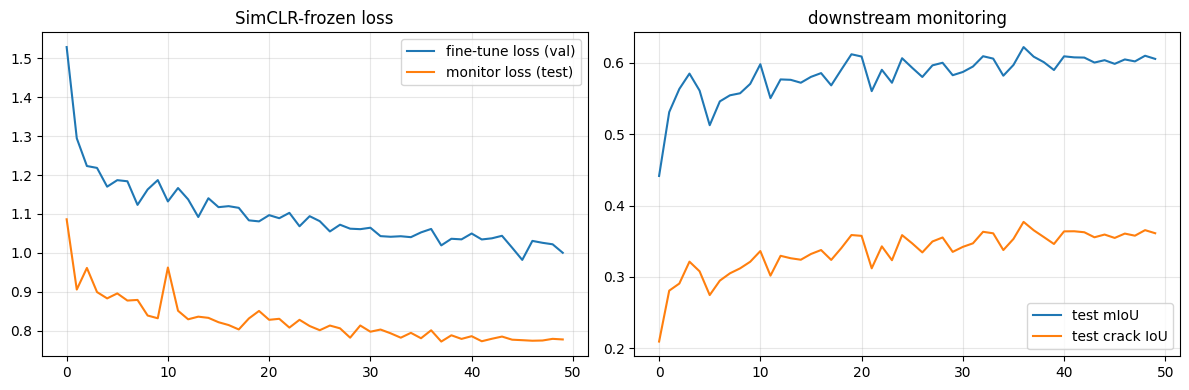

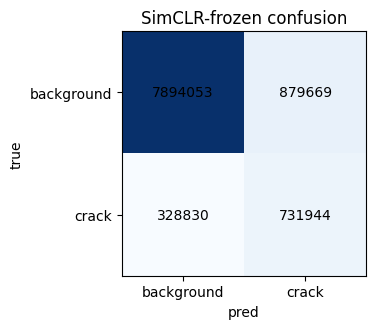

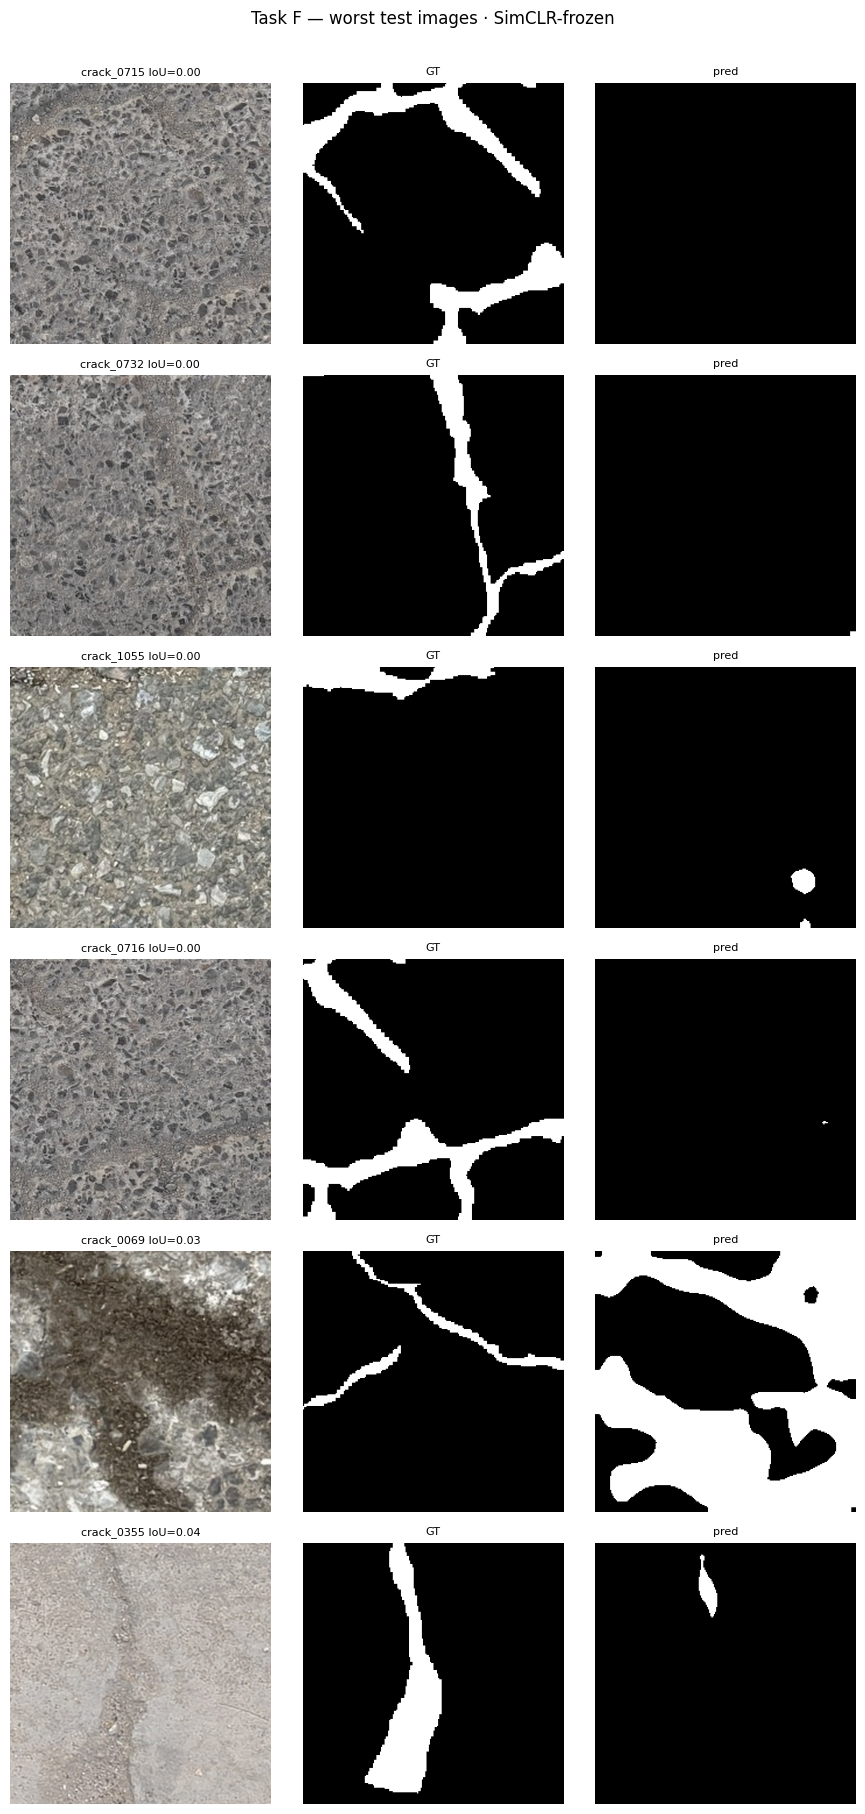

results_partB.json now has: ['SimCLR-frozen']

### Variant 2: FULL fine-tune (encoder + decoder, differential LR)
  transferred SSL encoder -> deeplab backbone | missing 0 unexpected 0
  [SimCLR] ep 01 train 1.526 | test mIoU 0.463 crackIoU 0.229
  [SimCLR] ep 05 train 1.139 | test mIoU 0.565 crackIoU 0.311
  [SimCLR] ep 10 train 1.055 | test mIoU 0.618 crackIoU 0.380
  [SimCLR] ep 15 train 0.972 | test mIoU 0.641 crackIoU 0.406
  [SimCLR] ep 20 train 0.952 | test mIoU 0.622 crackIoU 0.387
  [SimCLR] ep 25 train 0.921 | test mIoU 0.639 crackIoU 0.408
  [SimCLR] ep 30 train 0.898 | test mIoU 0.644 crackIoU 0.414
  [SimCLR] ep 35 train 0.900 | test mIoU 0.646 crackIoU 0.418
  [SimCLR] ep 40 train 0.913 | test mIoU 0.655 crackIoU 0.428
  [SimCLR] ep 45 train 0.871 | test mIoU 0.645 crackIoU 0.419
  [SimCLR] ep 50 train 0.870 | test mIoU 0.645 crackIoU 0.419
  [SimCLR] done 4.5 min | best test crack-IoU 0.4284 @ ep 40
=== Task E — SimCLR ===  mIoU 0.6547 | crackIoU 0.4284 | pixAcc 0.8908 |

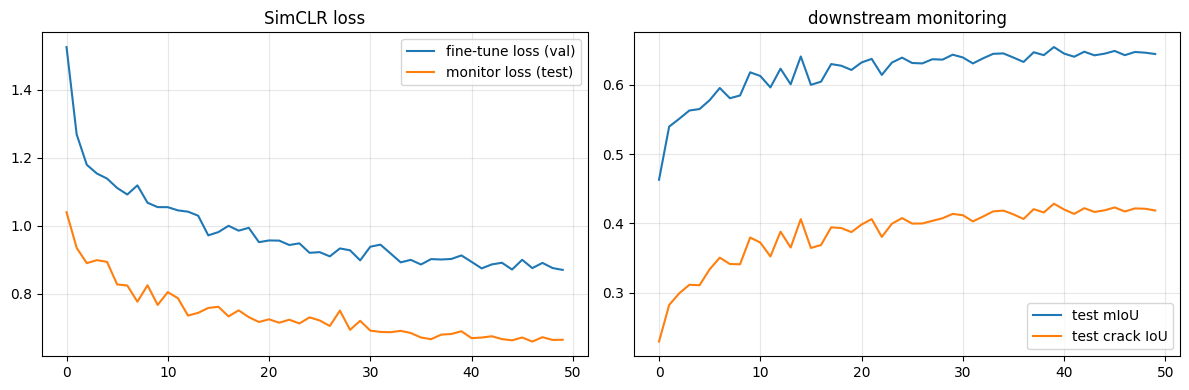

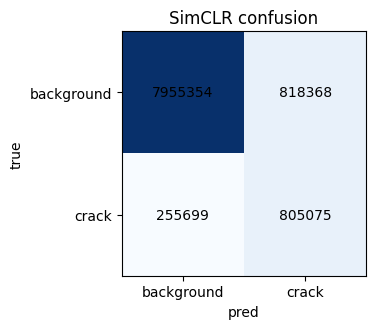

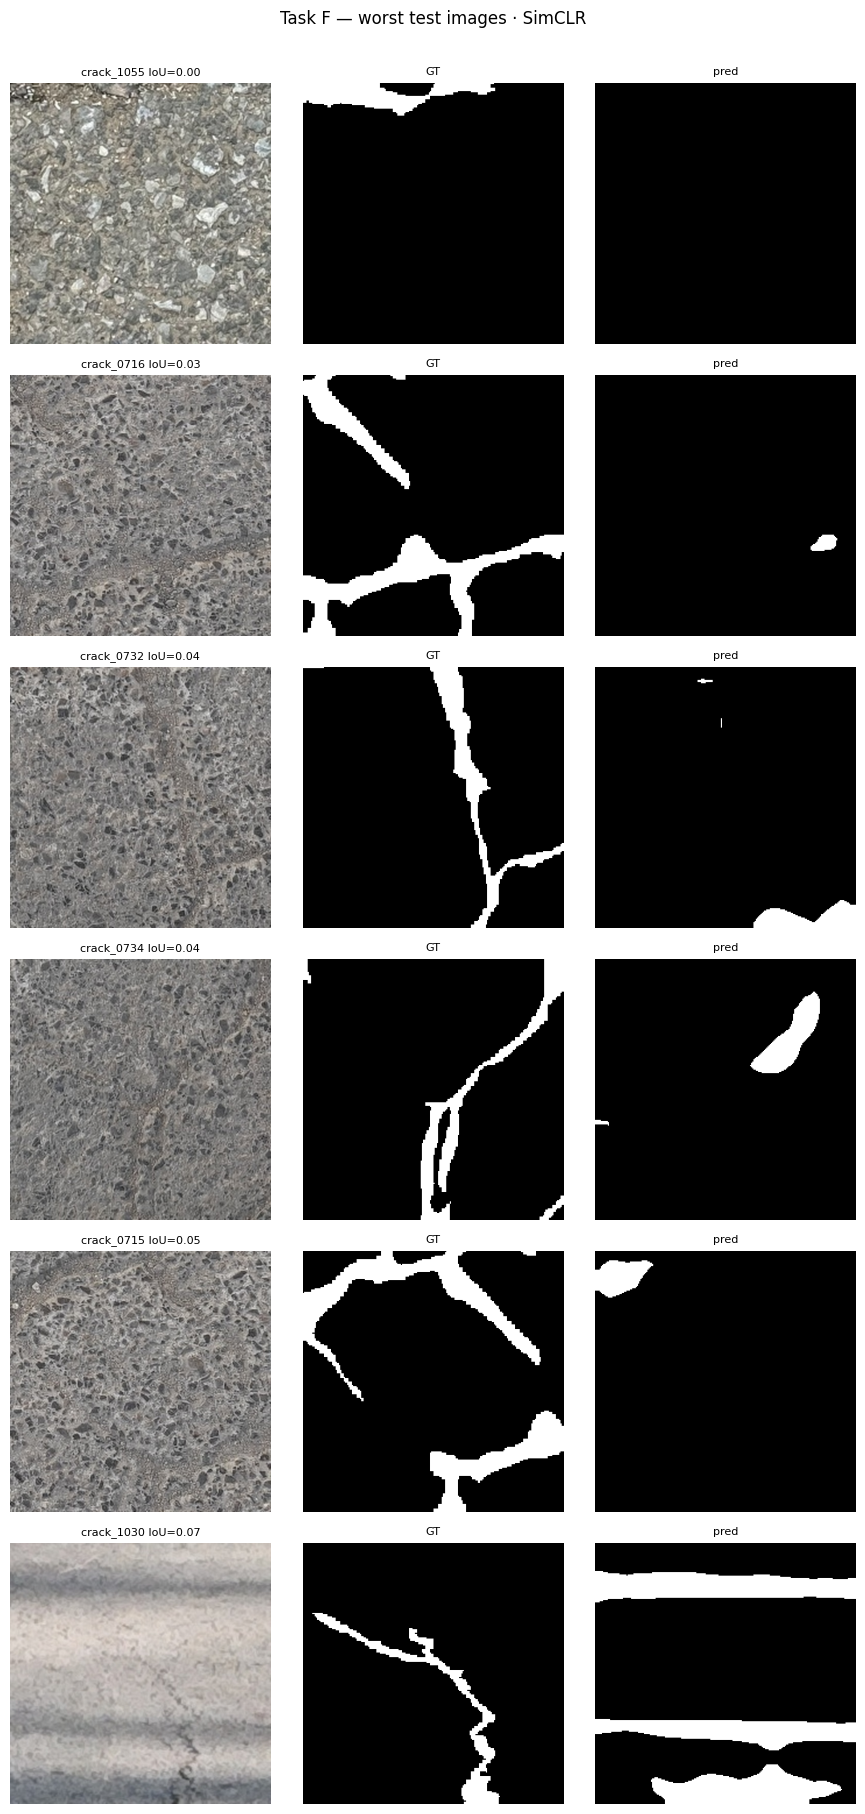

results_partB.json now has: ['SimCLR-frozen', 'SimCLR']


{'iou': [0.881048076061577, 0.42842690972795033],
 'miou': 0.6547374928947637,
 'dice': [0.9367629538807549, 0.5998583572043542],
 'mdice': 0.7683106555425545,
 'pixel_acc': 0.8907857606531133,
 'mean_pixel_acc': 0.8328378223480426}

In [9]:
# ---- FROZEN-vs-FINE-TUNED ablation (required on one method) ----
print("### Variant 1: FROZEN encoder (linear-probe of the ASPP decoder only)")
m_frozen = build_seg_from_resnet(pretrained_encoder, frozen=True)
m_frozen, h_f, min_f, ep_f = finetune(m_frozen, "SimCLR-frozen", enc_lr=0.0, dec_lr=1e-3)
model = m_frozen; evaluate_and_report(model, h_f, min_f, ep_f, tag="SimCLR-frozen")

print("\n### Variant 2: FULL fine-tune (encoder + decoder, differential LR)")
m_full = build_seg_from_resnet(pretrained_encoder, frozen=False)
m_full, h_u, min_u, ep_u = finetune(m_full, "SimCLR", enc_lr=1e-5, dec_lr=1e-3)
model = m_full; evaluate_and_report(model, h_u, min_u, ep_u, tag="SimCLR")

## SimCLR complete
SSL pretraining (50 ep) + downstream fine-tuning (50 ep on 195 labelled images) done; test metrics + worst-image
error analysis produced; appended to `results_partB.json`. **Commit** so the final-comparison notebook can pull it.